In [1]:
print("check")

check


SETUP OR FETCH ENV VARIABLES

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()


# Groq (model provider)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Search API keys
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")

print("Keys set!")

Keys set!


In [6]:
from langchain.chat_models import init_chat_model

# Use Groq LLM
model = init_chat_model(
    model="groq:llama-3.3-70b-versatile",  # Large model for tool calling
    temperature=0.3
)

print("LLM initialized:", model)

LLM initialized: profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x10b25da30> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10b3ba750> model_name='llama-3.3-70b-versatile' temperature=0.3 model_kwargs={} groq_api_key=SecretStr('**********')


In [7]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=5,
    topic="general"
)

print("Tavily search tool ready")

Tavily search tool ready


In [8]:
from langchain_community.utilities import GoogleSerperAPIWrapper

google_search = GoogleSerperAPIWrapper()

print("Google Serper wrapper ready")

Google Serper wrapper ready


In [10]:
result = google_search.run("give me latest news from the agrowon website")
print("Google Serper raw:", result)

Google Serper raw: Agrowon Epaper: Read all Agriculture Related News online in Marathi. Get all the Agriculture updates, Farming tips, weather updates, Animal Care tips, ... Missing: website | Show results with:website. Smart Village Project will bring transformation, says Pardeshi · February 6, 2017 ; Agrowon congratulates its Media Partner, The Sakal Media Group, on being ... Missing: website | Show results with:website. Parallel Market Price Scheme Demand: लासलगाव बाजार समितीच्या आवारातील पाण्याच्या टाकीवर चढून शिवसेना ठाकरे गट, शिवसेना शिंदे गट व छावा क्रांतिवीर सेनेच्या पदाधिकाऱ्यांनी शुक्रवारी (ता.२७) 'शोले स्टाईल' सुमारे तीन तास आंदोलन ... News · Careers · Home » Latest News » Smart Village Project will bring transformation, says Pardeshi. News. Agrowon App- The Best Daily Agri News App!!! 'The ... प्रधानमंत्री पिक विमा योजना काढणीपश्‍चात नुकसान भरपाई देणेबाबत प्रावधान आहे. यासंदर्भात माननीय आयुक्त कृषी व मुख्य संखिक यांनी सविस्तर माहिती वरील व्हिडिओ मध्ये दिली आहे . शेतकरी बंधू

In [11]:
result = tavily_search.run("give me latest news from the agrowon website")
print("Tavily search raw:", result)

Tavily search raw: {'query': 'give me latest news from the agrowon website', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://corporate.agrowon.com/news/', 'title': 'News - Agrowon', 'content': "News · Careers · Home » Latest News » Smart Village Project will bring transformation, says Pardeshi. News. Agrowon App- The Best Daily Agri News App!!! 'The", 'score': 0.7598145, 'raw_content': None}, {'url': 'https://corporate.agrowon.com/category/latest-news/', 'title': 'Latest News Archives - Agrowon', 'content': 'Smart Village Project will bring transformation, says Pardeshi · February 6, 2017 ; Agrowon congratulates its Media Partner, The Sakal Media Group, on being', 'score': 0.74785584, 'raw_content': None}, {'url': 'https://www.zoominfo.com/c/agrowon/356904623', 'title': 'Agrowon - Overview, News & Similar companies | ZoomInfo.com', 'content': 'Agrowon is a leading source of agriculture news in Marathi, providing the latest updates on farming, agr

In [14]:
from langchain_core.tools import Tool 


def tavily_search_tool(query: str) -> str:
    """
    Search the web using Tavily for travel info, tips, attractions, etc.
    """
    # Call the existing TavilySearch tool underneath
    return tavily_search.invoke({"query": query})


def google_serper_search_tool(query: str) -> str:
    """
    Search the web using Google Serper for up-to-date travel info.
    """
    return google_search.run(query)

In [12]:
from langchain.agents import create_agent

system_prompt = """
You are a travel planner assistant. User asks travel queries like
'plan my trip to X', 'what to do in Y hotel', etc.
Always use the available web search tools (TavilySearch, GoogleSerperSearch)
to look up latest real-world travel info. Provide a helpful and clear itinerary/answers.
"""

Travel planner agent ready!


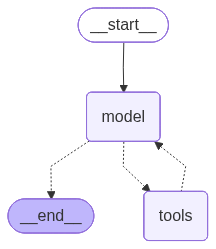

In [15]:
agent = create_agent(
    model=model,
    tools=[tavily_search_tool , google_serper_search_tool],
    system_prompt=system_prompt.strip()
)

print("Travel planner agent ready!")
agent

In [16]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Give me a 3 day plan for Kasol travel with places to see."}
    ]
})

print("Agent answer:\n")
print(response)

Agent answer:

{'messages': [HumanMessage(content='Give me a 3 day plan for Kasol travel with places to see.', additional_kwargs={}, response_metadata={}, id='8402d661-ef95-48ae-9a25-39611e9c3447'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd8d0752fa', 'function': {'arguments': '{"query":"Kasol travel plan 3 days"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'ym33sc6fj', 'function': {'arguments': '{"query":"places to visit in Kasol"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'nw3s31vxv', 'function': {'arguments': '{"query":"Kasol latest travel updates"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 391, 'total_tokens': 458, 'completion_time': 0.153217006, 'completion_tokens_details': None, 'prompt_time': 0.020689275, 'prompt_tokens_details': None, 'queue_time': 0.048665315, 'total_time': 0.173906281}, 'model_name': 'llama-3.3-70b-versat

In [19]:
final_answer = response["messages"][-1].content
print("\nFinal answer:\n")
print(final_answer)


Final answer:

Here's a 3-day plan for your trip to Kasol:

Day 1: 
- Arrive at Bhuntar and take a taxi or bus to Kasol.
- Check into your hotel and freshen up.
- Explore the Kasol market and visit cafes like Evergreen or Jim Morrison Cafe.
- Overnight stay at Kheerganga (plenty of camp sites available).

Day 2: 
- Trek down to Barshaini (3 hours).
- Option 1: Visit Tosh village, explore its chill cafes, and enjoy great views.
- Option 2: Visit Manikaran Sahib, a Gurudwara with hot springs.
- Return to Kasol by evening.

Day 3: 
- Visit the Parvati Valley, a gorgeous and must-visit place in Kasol.
- Explore other popular sightseeing places in Kasol like Malana Village, Kheer Ganga, Tirthan Valley, and more.
- Depart for your return journey.

Please note that the current road conditions and weather updates suggest that the roads to Kasol are inhospitable due to heavy and frequent snowfall in winters, and cold and dry winter winds make it a little difficult to explore the area. It's rec